In [1]:
# imports
from pathlib import Path
import sys  

# Get my_package directory path from Notebook
parent_dir = str(Path().resolve().parents[0])

# Add to sys.path
sys.path.insert(0, parent_dir)


In [6]:
from utils.experiment_utils import get_all_experiments_info, load_best_model

device = 'cuda'
configs = get_all_experiments_info('../outputs/', False)
cfgs = [
    c for c in configs if 'mvn' in c['name']    
        and c['config']['dataset']['n_sets'] == 50_000
        # and c['generator'] == 'DDPM'
        # and c['config']['dataset']['set_size'] == 500
]

In [7]:
cfgs

[{'name': 'mvn_coupled_exp_49cf11c99c0081513ef9ac72e4bafe1e',
  'dir': '../outputs/mvn_coupled_exp_49cf11c99c0081513ef9ac72e4bafe1e',
  'config': {'dataset': {'_target_': 'datasets.distribution_datasets.MultivariateNormalDistributionDataset', 'n_sets': 50000, 'set_size': '${experiment.set_size}', 'data_shape': [2], 'seed': '${seed}', 'prior_mu': [0, 5], 'prior_cov_df': 10, 'prior_cov_scale': 1}, 'encoder': {'_target_': 'encoder.encoders.DistributionEncoderGNN', 'in_dim': '${dataset.data_shape[0]}', 'latent_dim': '${experiment.latent_dim}', 'hidden_dim': '${experiment.hidden_dim}', 'set_size': '${experiment.set_size}', 'layers': 2, 'fc_layers': 2}, 'model': {'_target_': 'layers.MLP', 'in_dims': [2, 1, 16, 16], 'hidden_dim': 64, 'out_dim': 2, 'layers': 4}, 'coupling': {'_target_': 'types.NoneType'}, 'generator': {'_target_': 'generator.flow_matching.FlowMatchingGenerator', 'model': '${model}', 'sigma_min': 0.0001}, 'optimizer': {'_target_': 'torch.optim.Adam', '_partial_': True, 'lr': '$

In [17]:
import hydra
# load + prep dataset
def prepare_dataset(dataset_cfg):
    # probs = np.column_stack((np.linspace(0, 1, num_probs), 1 - np.linspace(0, 1, num_probs)))
    dataset = hydra.utils.instantiate(dataset_cfg)
    # dataset.probs = probs
    # dataset.data, _, _ = dataset.make_sets()
    return dataset

# load encoder and move to device
def load_model(cfg, path, device):
    enc = hydra.utils.instantiate(cfg['encoder'])
    gen = hydra.utils.instantiate(cfg['generator'])
    state = load_best_model(path)
    enc.load_state_dict(state['encoder_state_dict'])
    gen.load_state_dict(state['generator_state_dict'])
    enc.eval()
    gen.eval()
    enc.to(device)
    gen.to(device)
    return enc, gen

enc, gen = load_model(cfgs[0]['config'], cfgs[0]['dir'], device)


In [18]:
ds = prepare_dataset(cfgs[0]['config']['dataset'])

In [4]:
!ls /orcd/data/omarabu/001/njwfish/CoupledDistributionEmbeddings/data/by_write

hsf_0  hsf_1  hsf_2  hsf_3  hsf_4  hsf_6  hsf_7


In [19]:
s1 = ds.sample(ds.mu[2][None, :], ds.cov[2][None, :, :], 1, 1_000_000, (2,)).squeeze()
s2 = ds.sample(ds.mu[1][None, :], ds.cov[1][None, :, :], 1, 1_000_000, (2,)).squeeze()

In [ ]:
import numpy as np
import torch
lat = enc(torch.from_numpy(np.concatenate([s1[None, :, :], s2[None, :, :]], axis=0)).float().to(device))
lat_interp = lat[0] + (lat[1] - lat[0]) * torch.linspace(0, 1, 20)[:, None].to(device)
source_samples = torch.from_numpy(s1[None, :, :]).expand(20, -1, -1).reshape(-1, 2).float().to(device)
source_latent = lat[0][None, :].expand(20, -1)
resample = gen.sample(source_samples, source_latent, lat_interp)

In [44]:
import numpy as np

# X is (n, m, d)
def vectorized_covariance(X):
    # Center the data
    X_centered = X - X.mean(axis=1, keepdims=True)  # shape (n, m, d)

    # Compute covariance: cov = (X^T X) / (m - 1)
    cov = np.einsum('nmd,nme->nde', X_centered, X_centered) / (X.shape[1] - 1)
    return cov


# compute means and covariances of all the resampled points
resample_means = np.mean(resample.cpu().numpy(), axis=1)
resample_covs = vectorized_covariance(resample.cpu().numpy())

In [45]:
import numpy as np
from scipy.linalg import sqrtm

import numpy as np
from scipy.linalg import sqrtm

def generate_ot_trajectory(mean1, cov1, mean2, cov2, n_steps=10):
    """
    Generate the correct Optimal Transport trajectory between two Gaussian distributions.
    
    Parameters:
    -----------
    mean1 : array-like
        Initial mean (2D vector)
    cov1 : array-like
        Initial covariance matrix (2x2)
    mean2 : array-like
        Final mean (2D vector)
    cov2 : array-like
        Final covariance matrix (2x2)
    n_steps : int
        Number of interpolation steps
        
    Returns:
    --------
    means : array-like
        List of interpolated means
    covs : array-like
        List of interpolated covariance matrices
    """
    mean1 = np.array(mean1)
    mean2 = np.array(mean2)
    cov1 = np.array(cov1)
    cov2 = np.array(cov2)
    
    # Generate interpolation parameters
    ts = np.linspace(0, 1, n_steps)
    
    # Initialize lists for means and covariances
    means = []
    covs = []
    
    # Compute the square root of cov1
    sqrt_cov1 = sqrtm(cov1)
    inv_sqrt_cov1 = np.linalg.inv(sqrt_cov1)
    
    # Compute A = (cov1^(1/2) * cov2 * cov1^(1/2))^(1/2)
    A = sqrtm(sqrt_cov1 @ cov2 @ sqrt_cov1)
    
    for t in ts:
        # Interpolate means linearly
        mean_t = (1 - t) * mean1 + t * mean2
        
        # Correct interpolation formula for covariances
        inner = ((1 - t) * cov1 + t * sqrtm(sqrt_cov1 @ cov2 @ sqrt_cov1))
        cov_t = inv_sqrt_cov1 @ (inner @ inner) @ inv_sqrt_cov1
        
        means.append(mean_t)
        covs.append(cov_t)
    
    return np.array(means), np.array(covs)

ot_means, ot_covs = generate_ot_trajectory(ds.mu[2], ds.cov[2], ds.mu[1], ds.cov[1], 20)

In [54]:
import numpy as np

# load from numerical results
# ot_means, ot_covs = np.load('numerical_results/mvn_ot.npz')['ot_means'], np.load('numerical_results/mvn_ot.npz')['ot_covs']
# resample_means, resample_covs = np.load('numerical_results/mvn_ot.npz')['gde_means'], np.load('numerical_results/mvn_ot.npz')['gde_covs']

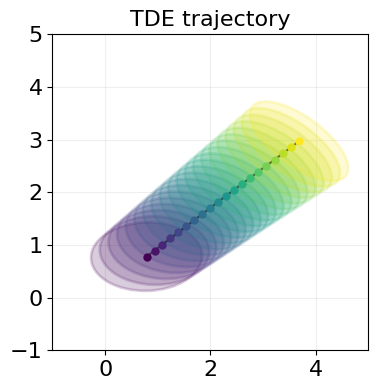

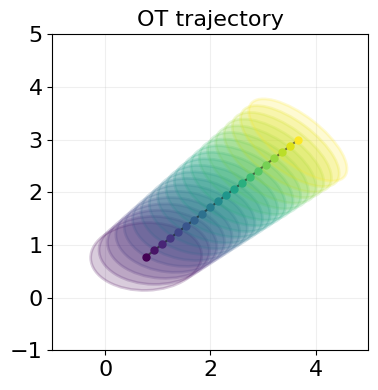

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import matplotlib.colors as mcolors


plt.rc('xtick', labelsize=16)
plt.rc('ytick', labelsize=16)
plt.rc('axes', titlesize=16)

def plot_gaussian_trajectories(means, covs, figsize=(8, 8), alpha=0.2, n_std=2, title=None):
    """
    Plot trajectories of Gaussian distributions with their confidence ellipses.
    
    Parameters:
    -----------
    means : array-like
        List of 2D means, shape (n_timesteps, 2)
    covs : array-like
        List of 2x2 covariance matrices, shape (n_timesteps, 2, 2)
    figsize : tuple
        Figure size (width, height)
    alpha : float
        Transparency of ellipses
    n_std : float
        Number of standard deviations for ellipse size
    """
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create color gradient
    colors = plt.cm.viridis(np.linspace(0, 1, len(means)))
    
    # Plot trajectories and ellipses
    for i in range(len(means)):
        mean = means[i]
        cov = covs[i]
        
        # Calculate eigenvalues and eigenvectors
        eigenvals, eigenvecs = np.linalg.eigh(cov)
        
        # Calculate angle and axes lengths for ellipse
        angle = np.degrees(np.arctan2(eigenvecs[1, 0], eigenvecs[0, 0]))
        width, height = 2 * n_std * np.sqrt(eigenvals)
        
        # Create and add ellipse
        ellipse = Ellipse(xy=mean,
                         width=width,
                         height=height,
                         angle=angle,
                         facecolor=colors[i],
                         alpha=alpha,
                         edgecolor=colors[i],
                         linewidth=2,
                         zorder=10)
        ax.add_patch(ellipse)
        
        # Plot mean point
        ax.plot(mean[0], mean[1], 'o', color=colors[i], markersize=5, zorder=50)
        
    # Plot trajectory line
    means_array = np.array(means)
    ax.plot(means_array[:, 0], means_array[:, 1], '-', color='black', alpha=0.5, zorder=49)
    
    # Set equal aspect ratio and grid
    # ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)
    ax.set_aspect('equal')
    ax.set_xlim(-1, 5)
    ax.set_ylim(-1, 5)
    
    # Add colorbar to show time progression
    # sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, 
    #                           norm=plt.Normalize(vmin=0, vmax=len(means)-1))
    
    # plt.colorbar(sm, ax=ax, label='Time step')  # Added ax=ax here

    if title is not None:
        ax.set_title(title)

    plt.tight_layout()
    
    return fig


fig = plot_gaussian_trajectories(resample_means, resample_covs, title='TDE trajectory', figsize=(4,4))
plt.savefig('../figs/mvn_tde.png', dpi=300)

fig_ot = plot_gaussian_trajectories(ot_means, ot_covs, title='OT trajectory', figsize=(4,4))
plt.savefig('../figs/mvn_ot.png', dpi=300)

# # save actual data to numerical results
np.savez(
    '../numerical_results/mvn_ot.npz', 
    ot_means=ot_means, 
    ot_covs=ot_covs, 
    gde_means=resample_means, 
    gde_covs=resample_covs
)


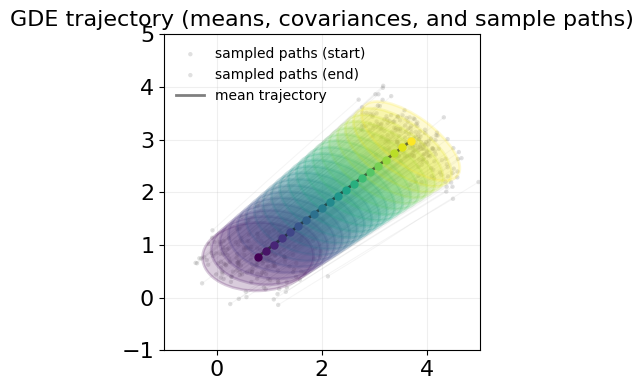

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import matplotlib.colors as mcolors

plt.rc('xtick', labelsize=16)
plt.rc('ytick', labelsize=16)
plt.rc('axes', titlesize=16)

def _prepare_trajectories(samples, n_traj_to_plot=200, rng=None):
    """
    Convert raw samples into a (n_traj_to_plot, T, 2) array of trajectories.

    Accepts either:
      - samples shape (T, N, 2): independent draws at each time t
        -> we stitch trajectories by matching indices across time for a subsample of N
      - samples shape (N, T, 2): full per-sample paths already

    Returns:
      trajs: (K, T, 2) with K = min(n_traj_to_plot, available)
    """
    if rng is None:
        rng = np.random.default_rng()

    samples = np.asarray(samples)
    if samples.ndim != 3 or samples.shape[-1] != 2:
        raise ValueError("samples must be 3D and last dim=2 (got shape {})".format(samples.shape))

    # Case A: (T, N, 2)
    if samples.shape[0] < samples.shape[1]:
        T, N, _ = samples.shape
        K = min(n_traj_to_plot, N)
        idx = rng.choice(N, size=K, replace=False)
        # gather trajectories for those idx across time
        trajs = samples[:, idx, :]            # (T, K, 2)
        trajs = np.transpose(trajs, (1, 0, 2)) # (K, T, 2)
        return trajs

    # Case B: (N, T, 2)
    else:
        N, T, _ = samples.shape
        K = min(n_traj_to_plot, N)
        idx = rng.choice(N, size=K, replace=False)
        trajs = samples[idx, :, :]            # (K, T, 2)
        return trajs


def plot_gaussian_trajectories(
    means,
    covs,
    samples=None,
    n_traj_to_plot=200,
    traj_alpha=0.05,
    traj_linewidth=1.0,
    traj_color="gray",
    figsize=(8, 8),
    alpha=0.2,
    n_std=2,
    title=None,
    xlim=(-1, 5),
    ylim=(-1, 5),
):
    """
    Plot trajectories of Gaussian distributions with their confidence ellipses,
    plus (optionally) sample trajectories.

    Parameters
    ----------
    means : array-like, shape (T, 2)
        Sequence of means over time.
    covs : array-like, shape (T, 2, 2)
        Sequence of 2x2 covariance matrices over time.
    samples : array-like, optional
        Either shape (T, N, 2) or (N, T, 2).
        Used to overlay actual particle trajectories.
    n_traj_to_plot : int
        How many particle trajectories to randomly overlay.
    traj_alpha : float
        Alpha for the trajectory lines.
    traj_linewidth : float
        Line width for particle trajectories.
    traj_color : str or tuple
        Color for particle trajectories (underlay).
    figsize : tuple
        Matplotlib figsize.
    alpha : float
        Alpha for covariance ellipses.
    n_std : float
        Radius of ellipse in std dev units.
    title : str
        Plot title.
    xlim, ylim : tuple
        Axis limits.
    """

    means = np.asarray(means)
    covs = np.asarray(covs)

    if means.ndim != 2 or means.shape[1] != 2:
        raise ValueError("means should have shape (T, 2); got {}".format(means.shape))
    if covs.ndim != 3 or covs.shape[1:] != (2, 2):
        raise ValueError("covs should have shape (T, 2, 2); got {}".format(covs.shape))
    if len(means) != len(covs):
        raise ValueError("means and covs must have same length in time")

    T = len(means)

    fig, ax = plt.subplots(figsize=figsize)

    # --- 1. (Optional) plot sample trajectories, faint, behind everything ---
    if samples is not None:
        trajs = _prepare_trajectories(samples, n_traj_to_plot=n_traj_to_plot)
        # trajs: (K, T, 2)
        for k in range(trajs.shape[0]):
            ax.plot(
                trajs[k, :, 0],
                trajs[k, :, 1],
                color=traj_color,
                alpha=traj_alpha,
                linewidth=traj_linewidth,
                zorder=1,
            )

        # also scatter start and end of the subsampled trajectories (helps show coverage)
        ax.scatter(
            trajs[:, 0, 0],
            trajs[:, 0, 1],
            s=10,
            color=traj_color,
            alpha=min(1.0, traj_alpha * 3),
            edgecolors="none",
            zorder=2,
            label="sampled paths (start)",
        )
        ax.scatter(
            trajs[:, -1, 0],
            trajs[:, -1, 1],
            s=10,
            color=traj_color,
            alpha=min(1.0, traj_alpha * 3),
            edgecolors="none",
            zorder=2,
            label="sampled paths (end)",
        )

    # --- 2. color gradient for time-stamped Gaussians ---
    colors = plt.cm.viridis(np.linspace(0, 1, T))

    # --- 3. plot ellipses + mean dots ---
    for i in range(T):
        mean = means[i]
        cov = covs[i]

        # eigh for symmetric 2x2
        eigenvals, eigenvecs = np.linalg.eigh(cov)

        # orientation (radians -> degrees)
        angle = np.degrees(np.arctan2(eigenvecs[1, 0], eigenvecs[0, 0]))

        # ellipse axes: 2 * n_std * sqrt(lambda)
        width, height = 2 * n_std * np.sqrt(eigenvals)

        ellipse = Ellipse(
            xy=mean,
            width=width,
            height=height,
            angle=angle,
            facecolor=colors[i],
            alpha=alpha,
            edgecolor=colors[i],
            linewidth=2,
            zorder=10,
        )
        ax.add_patch(ellipse)

        # mean point
        ax.plot(
            mean[0],
            mean[1],
            "o",
            color=colors[i],
            markersize=5,
            zorder=50,
        )

    # --- 4. connect the means with a black curve ---
    ax.plot(
        means[:, 0],
        means[:, 1],
        "-",
        color="black",
        alpha=0.5,
        linewidth=2,
        zorder=49,
        label="mean trajectory",
    )

    # --- 5. cosmetics ---
    ax.grid(True, alpha=0.2)
    ax.set_aspect("equal")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)

    if title is not None:
        ax.set_title(title)

    # optional legend: only if samples provided
    if samples is not None:
        # we already added labels for "sampled paths (start)" etc.
        # but Matplotlib will duplicate them for each scatter call unless we dedupe
        handles, labels = ax.get_legend_handles_labels()
        # dedupe while preserving order
        seen = set()
        uniq_handles = []
        uniq_labels = []
        for h, l in zip(handles, labels):
            if l not in seen and l != "":
                uniq_handles.append(h)
                uniq_labels.append(l)
                seen.add(l)
        ax.legend(
            uniq_handles,
            uniq_labels,
            frameon=False,
            fontsize=10,
            loc="best"
        )

    plt.tight_layout()
    return fig


# === USAGE EXAMPLE =====================================================
# Suppose you already have:
#   resample_means : (T, 2)
#   resample_covs  : (T, 2, 2)
# and also
#   latent_samples : either (T, N, 2) or (N, T, 2)
# where N could be 1_000_000

fig = plot_gaussian_trajectories(
    means=resample_means,
    covs=resample_covs,
    samples=resample.cpu().numpy(),        # <--- NEW
    n_traj_to_plot=200,            # downsample so we don't melt the GPU :)
    traj_alpha=0.08,
    traj_linewidth=0.75,
    traj_color="gray",
    figsize=(4, 4),
    title="GDE trajectory (means, covariances, and sample paths)",
    xlim=(-1, 5),
    ylim=(-1, 5),
)

plt.savefig("../figs/mvn_tde.png", dpi=300)

# save numerical results like before
np.savez(
    "../numerical_results/mvn_ot.npz",
    ot_means=ot_means,
    ot_covs=ot_covs,
    gde_means=resample_means,
    gde_covs=resample_covs,
)
